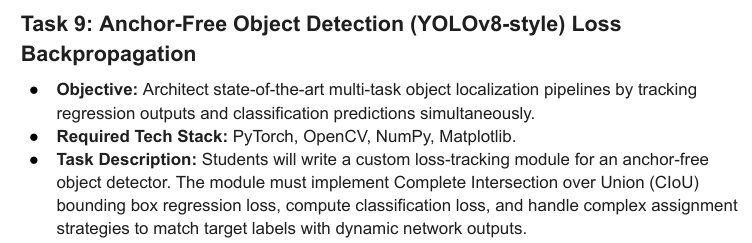

In [1]:
!pip install torch opencv-python numpy matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import cv2
import matplotlib.pyplot as plt

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cpu


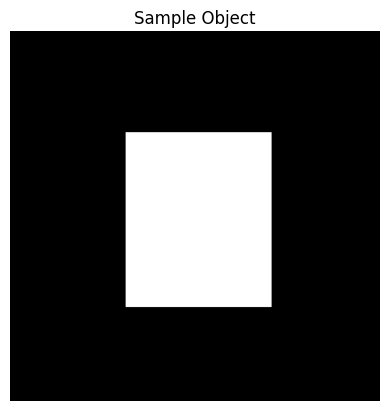

In [4]:
image = np.zeros(
    (256, 256, 3),
    dtype=np.uint8
)

# Draw a sample object
cv2.rectangle(
    image,
    (80, 70),
    (180, 190),
    (255, 255, 255),
    -1
)

plt.imshow(
    cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Sample Object")

plt.axis("off")

plt.show()

In [5]:
target_box = torch.tensor(
    [80., 70., 180., 190.]
).to(device)

target_class = torch.tensor(
    0
).to(device)

print("Target box:", target_box)
print("Target class:", target_class.item())

Target box: tensor([ 80.,  70., 180., 190.])
Target class: 0


In [6]:
num_predictions = 10

pred_boxes = torch.tensor(
    [
        [75, 65, 185, 195],
        [20, 20, 60, 60],
        [70, 80, 175, 185],
        [150, 150, 220, 240],
        [50, 40, 100, 100],
        [85, 75, 175, 180],
        [10, 100, 50, 150],
        [100, 50, 160, 130],
        [180, 20, 240, 80],
        [60, 160, 120, 230]
    ],
    dtype=torch.float32
).to(device)

In [7]:
pred_class_logits = torch.randn(
    num_predictions,
    1,
    device=device
)

print(
    "Prediction shape:",
    pred_class_logits.shape
)

Prediction shape: torch.Size([10, 1])


In [8]:
def calculate_iou(
    box1,
    box2
):

    x1 = torch.max(
        box1[0],
        box2[0]
    )

    y1 = torch.max(
        box1[1],
        box2[1]
    )

    x2 = torch.min(
        box1[2],
        box2[2]
    )

    y2 = torch.min(
        box1[3],
        box2[3]
    )

    intersection_width = torch.clamp(
        x2 - x1,
        min=0
    )

    intersection_height = torch.clamp(
        y2 - y1,
        min=0
    )

    intersection = (
        intersection_width
        *
        intersection_height
    )

    area1 = (
        box1[2] - box1[0]
    ) * (
        box1[3] - box1[1]
    )

    area2 = (
        box2[2] - box2[0]
    ) * (
        box2[3] - box2[1]
    )

    union = (
        area1
        +
        area2
        -
        intersection
    )

    return intersection / (
        union + 1e-7
    )

In [9]:
iou = calculate_iou(
    pred_boxes[0],
    target_box
)

print(
    "IoU:",
    iou.item()
)

IoU: 0.8391608595848083


In [32]:
def ciou_loss(
    pred,
    target
):

    # IoU

    iou = calculate_iou(
        pred,
        target
    )

    # Center points

    pred_cx = (
        pred[0] + pred[2]
    ) / 2

    pred_cy = (
        pred[1] + pred[3]
    ) / 2

    target_cx = (
        target[0] + target[2]
    ) / 2

    target_cy = (
        target[1] + target[3]
    ) / 2

    center_distance = (
        (pred_cx - target_cx) ** 2
        +
        (pred_cy - target_cy) ** 2
    )

    # Enclosing box diagonal


    enclose_x1 = torch.min(
        pred[0],
        target[0]
    )

    enclose_y1 = torch.min(
        pred[1],
        target[1]
    )

    enclose_x2 = torch.max(
        pred[2],
        target[2]
    )

    enclose_y2 = torch.max(
        pred[3],
        target[3]
    )

    diagonal = (
        (enclose_x2 - enclose_x1) ** 2
        +
        (enclose_y2 - enclose_y1) ** 2
        +
        1e-7
    )

    # Aspect ratio


    pred_width = (
        pred[2] - pred[0]
    )

    pred_height = (
        pred[3] - pred[1]
    )

    target_width = (
        target[2] - target[0]
    )

    target_height = (
        target[3] - target[1]
    )

    v = (
        4 / (torch.pi ** 2)
    ) * torch.pow(
        torch.atan(
            target_width /
            (target_height + 1e-7)
        )
        -
        torch.atan(
            pred_width /
            (pred_height + 1e-7)
        ),
        2
    )


    # Alpha

    alpha = v / (
        1 - iou + v + 1e-7
    )

    # CIoU


    ciou = (
        iou
        -
        center_distance / diagonal
        -
        alpha * v
    )

    return 1 - ciou

In [11]:
loss = ciou_loss(
    pred_boxes[0],
    target_box
)

print(
    "CIoU Loss:",
    loss.item()
)

CIoU Loss: 0.16083914041519165


In [12]:
ious = []

for box in pred_boxes:

    iou = calculate_iou(
        box,
        target_box
    )

    ious.append(iou)

ious = torch.stack(ious)

print("IoUs:")
print(ious)

IoUs:
tensor([0.8392, 0.0000, 0.7644, 0.0702, 0.0417, 0.7875, 0.0000, 0.2727, 0.0000,
        0.0800])


In [13]:
best_index = torch.argmax(
    ious
)

print(
    "Best prediction index:",
    best_index.item()
)

print(
    "Best IoU:",
    ious[best_index].item()
)

Best prediction index: 0
Best IoU: 0.8391608595848083


In [14]:
class_targets = torch.zeros(
    num_predictions,
    1,
    device=device
)

In [15]:
class_targets[
    best_index
] = 1

In [16]:
classification_loss = (
    F.binary_cross_entropy_with_logits(
        pred_class_logits,
        class_targets
    )
)

print(
    "Classification Loss:",
    classification_loss.item()
)

Classification Loss: 0.8187515139579773


In [17]:
positive_box = pred_boxes[
    best_index
]

box_loss = ciou_loss(
    positive_box,
    target_box
)

print(
    "Box Regression Loss:",
    box_loss.item()
)

Box Regression Loss: 0.16083914041519165


In [18]:
total_loss = (
    box_loss
    +
    classification_loss
)

print(
    "Total Loss:",
    total_loss.item()
)

Total Loss: 0.979590654373169


In [19]:
class SimpleDetector(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Conv2d(
                3,
                16,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                16,
                32,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.box_head = nn.Linear(
            32,
            4
        )

        self.class_head = nn.Linear(
            32,
            1
        )

    def forward(self, x):

        features = self.network(x)

        features = features.flatten(
            1
        )

        boxes = self.box_head(
            features
        )

        classes = self.class_head(
            features
        )

        return boxes, classes

In [20]:
detector = SimpleDetector().to(device)

print(detector)

SimpleDetector(
  (network): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (box_head): Linear(in_features=32, out_features=4, bias=True)
  (class_head): Linear(in_features=32, out_features=1, bias=True)
)


In [21]:
image_tensor = torch.tensor(
    image,
    dtype=torch.float32
).permute(
    2, 0, 1
).unsqueeze(0)

image_tensor = (
    image_tensor / 255.0
).to(device)

print(
    "Image shape:",
    image_tensor.shape
)

Image shape: torch.Size([1, 3, 256, 256])


In [22]:
pred_box, pred_class = detector(
    image_tensor
)

print(
    "Predicted box:",
    pred_box
)

print(
    "Predicted class:",
    pred_class
)

Predicted box: tensor([[-0.1650, -0.0642,  0.0026,  0.0107]], grad_fn=<AddmmBackward0>)
Predicted class: tensor([[0.1997]], grad_fn=<AddmmBackward0>)


In [23]:
target_box_normalized = (
    target_box / 256
)

print(
    target_box_normalized
)

tensor([0.3125, 0.2734, 0.7031, 0.7422])


In [24]:
box_training_loss = F.smooth_l1_loss(
    pred_box.squeeze(),
    target_box_normalized
)

In [25]:
class_training_loss = (
    F.binary_cross_entropy_with_logits(
        pred_class.squeeze(),
        torch.tensor(
            1.0,
            device=device
        )
    )
)

In [26]:
training_loss = (
    box_training_loss
    +
    class_training_loss
)

print(
    "Training Loss:",
    training_loss.item()
)

Training Loss: 0.7692641019821167


In [27]:
optimizer = torch.optim.Adam(
    detector.parameters(),
    lr=0.001
)

optimizer.zero_grad()

training_loss.backward()

optimizer.step()

print(
    "Backpropagation completed!"
)

Backpropagation completed!


In [28]:
loss_history = []

for epoch in range(50):

    pred_box, pred_class = detector(
        image_tensor
    )

    box_loss = F.smooth_l1_loss(
        pred_box.squeeze(),
        target_box_normalized
    )

    class_loss = (
        F.binary_cross_entropy_with_logits(
            pred_class.squeeze(),
            torch.tensor(
                1.0,
                device=device
            )
        )
    )

    loss = (
        box_loss
        +
        class_loss
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    loss_history.append(
        loss.item()
    )

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch+1}/50 "
            f"Loss: {loss.item():.4f}"
        )

Epoch 10/50 Loss: 0.6308
Epoch 20/50 Loss: 0.4147
Epoch 30/50 Loss: 0.2182
Epoch 40/50 Loss: 0.0961
Epoch 50/50 Loss: 0.0349


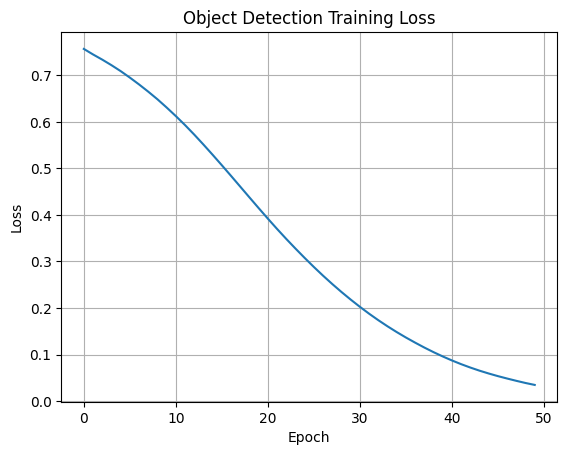

In [29]:
plt.plot(
    loss_history
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Object Detection Training Loss"
)

plt.grid()

plt.show()

In [30]:
detector.eval()

with torch.no_grad():

    pred_box, pred_class = detector(
        image_tensor
    )

pred_box = (
    pred_box.squeeze()
    .cpu()
    .numpy()
)

# Convert normalized coordinates
pred_box = pred_box * 256

print(
    "Predicted box:",
    pred_box
)

Predicted box: [ 82.49037   62.725548 175.49655  224.35619 ]


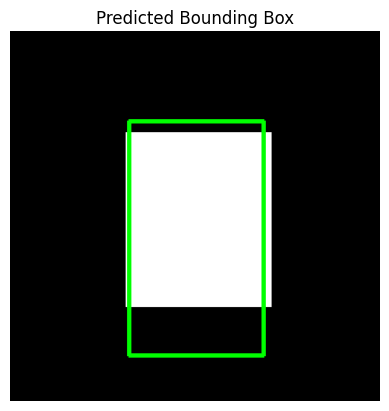

In [31]:
visual = image.copy()

x1, y1, x2, y2 = (
    pred_box.astype(int)
)

cv2.rectangle(
    visual,
    (x1, y1),
    (x2, y2),
    (0, 255, 0),
    2
)

plt.imshow(
    cv2.cvtColor(
        visual,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Predicted Bounding Box"
)

plt.axis("off")

plt.show()